In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h3
import xgboost as xgb
from tqdm import tqdm
import seaborn as sns
import re
import datetime
import os
import random
import h3

In [3]:
h3_l7_df = pd.read_csv('../../data/processed/h3_l7_df_new.csv')
h3_l7_df.drop(columns=['commercial;yes'], inplace=True)
h3_l7_df

,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,warehouse,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca
0,872af0424ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,872af0425ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,872af0426ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,872af0500ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,872af0501ffffff,0,0,1,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,872af6373ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
173,872af6375ffffff,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,20
174,872af6acaffffff,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
175,872af6ad9ffffff,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,2


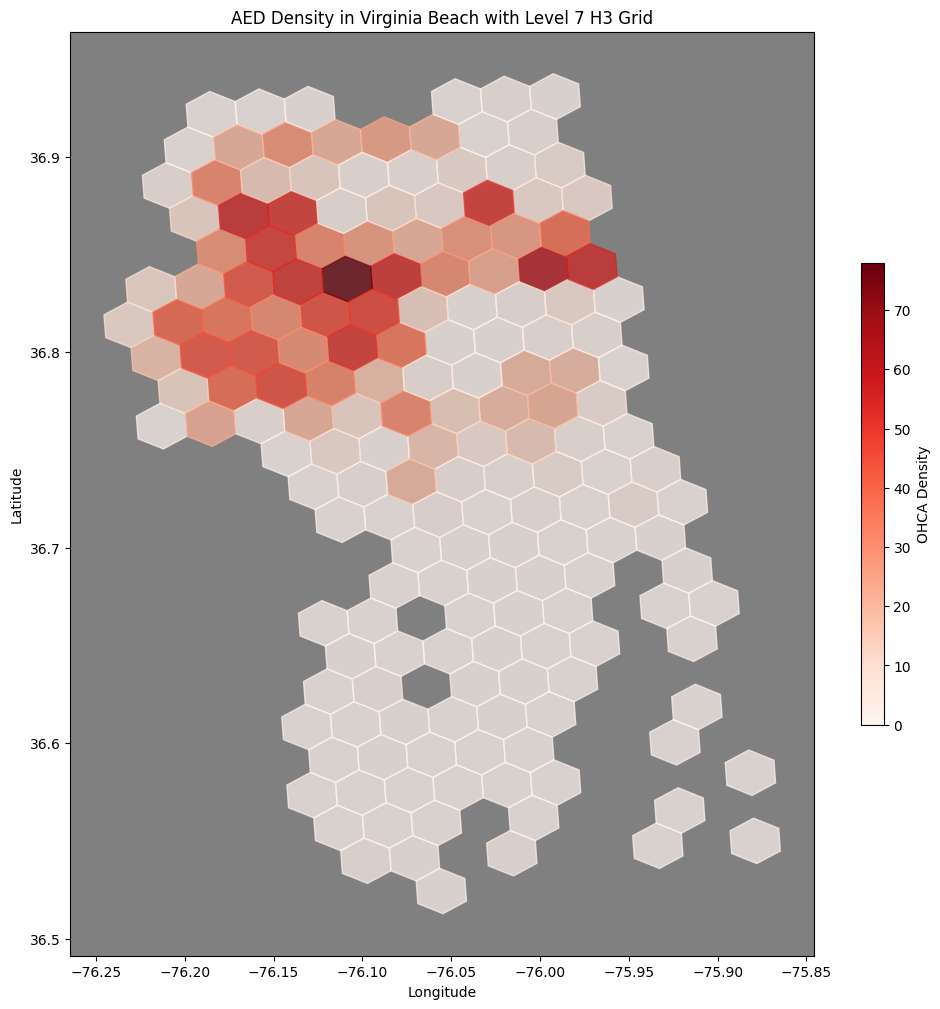

In [4]:
from shapely.geometry import Polygon
import matplotlib.colors as mcolors
import osmnx as ox

districts = ox.geocode_to_gdf([
    'Virginia Beach, Virginia, USA',
])
# Step 3: 繪製行政區背景
fig, ax = plt.subplots(figsize=(12, 12))


# Step 4: 計算各網格內的 AED 密度
density = h3_l7_df[['id', 'ohca']]

# Step 5: 繪製每個網格
for index, row in density.iterrows():
    # 將 H3 索引轉換為多邊形
    boundary = h3.h3_to_geo_boundary(row['id'], geo_json=True)
    polygon = Polygon(boundary)
    # 根據密度決定顏色
    color_norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
    color = plt.cm.Reds(color_norm(row['ohca']))
    ax.fill(*zip(*polygon.exterior.coords), color=color, alpha=0.7)

# Step 6: 創建並顯示顏色條
norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation='vertical', label='OHCA Density', shrink=0.5)

# Step 7: 設定地圖的細節
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('AED Density in Virginia Beach with Level 7 H3 Grid')
ax.set_facecolor('grey')

# 顯示地圖
plt.show()

In [5]:
train_index=[]
test_index=[]
for i in range(0,h3_l7_df.shape[0]):
    geo_location = h3.h3_to_geo(h3_l7_df.iloc[i]['id'])

    if (geo_location[1]) > (-76.05): #把經度大於-76.05的 當train (東邊是train)
        train_index.append(i)
    else:
        test_index.append(i)

# 分割訓練集和測試集
train_h3_l7_df = h3_l7_df.iloc[train_index]
test_h3_l7_df = h3_l7_df.iloc[test_index]

# 將 h3_l7_df 資料框中的 'id' 列移除，僅保留數據進行正規化
h3_spatial_data = h3_l7_df.drop('id', axis=1)


# # # 對數據進行正規化：將每個數據列的最小值調整為 0，最大值調整為 1
normalized_spatial_data = (h3_spatial_data - h3_spatial_data.min()) / (h3_spatial_data.max() - h3_spatial_data.min())

#設定OHCA正規化反函數 方便把預測結果返回原本scale
ohca_reguli_inverse = (h3_l7_df.ohca.max()-h3_l7_df.ohca.min()) + h3_l7_df.ohca.min()

# 將 DataFrame 轉換為 numpy array，並設定數據類型為 np.float64
spatial_data = np.array(normalized_spatial_data).astype(np.float64)


train_spatial_data = spatial_data[train_index]
test_spatial_data = spatial_data[test_index]

# 分离特征和标签
X = spatial_data[:, :-1]  # 特征
Y = spatial_data[:, -1]   # 标签（OHCA）

X_train_reguli = train_spatial_data[:, :-1] 
y_train_reguli = train_spatial_data[:, -1] 
X_test_reguli = test_spatial_data[:, :-1] 
y_test_reguli = test_spatial_data[:, -1] 

# SVM

In [6]:
import shap
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# 正規化數據 (將特徵縮放到相同範圍，以提高模型的穩定性)
scaler = StandardScaler()
normalized_spatial_data = scaler.fit_transform(h3_spatial_data)

# 設定 SVR 參數
kernel = 'linear'  # 指定核函數
C = 1  # 指定 C 參數
epsilon = 0.05  # 指定 epsilon 參數

# 初始化 SVR 模型
svr = SVR(kernel=kernel, C=C, epsilon=epsilon)

# 訓練模型
svr.fit(X_train_reguli, y_train_reguli)

y_head_train = svr.predict(X_train_reguli) * ohca_reguli_inverse
y_train = y_train_reguli * ohca_reguli_inverse
# 預測測試集結果
y_head_test = svr.predict(X_test_reguli) * ohca_reguli_inverse
y_test = y_test_reguli * ohca_reguli_inverse



#評估成效
train_mae = np.abs(y_head_train-y_train)
train_ans_mae = train_mae.sum()/train_mae.shape[0]
print('MAE of train set= ',train_ans_mae)
# 計算殘差變異
train_ss_residual = np.sum((y_train - y_head_train) ** 2)
# 計算總變異量
train_ss_total = np.sum((y_train - np.mean(y_train)) ** 2)
# 計算 R²
train_r_squared = 1 - (train_ss_residual / train_ss_total)
print("R² of train set= ", train_r_squared)

test_mae = np.abs(y_head_test-y_test)
test_ans_mae = test_mae.sum()/test_mae.shape[0]
print('MAE of test set= ',test_ans_mae)
# 計算殘差變異
test_ss_residual = np.sum((y_test - y_head_test) ** 2)
# 計算總變異量
test_ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
# 計算 R²
test_r_squared = 1 - (test_ss_residual / test_ss_total)
print("R² of test set= ", test_r_squared)

MAE of train set=  2.155442200780529
R² of train set=  0.9567643526560218
MAE of test set=  5.9113057370852164
R² of test set=  0.7306680741512512


c:\Users\Yuan\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


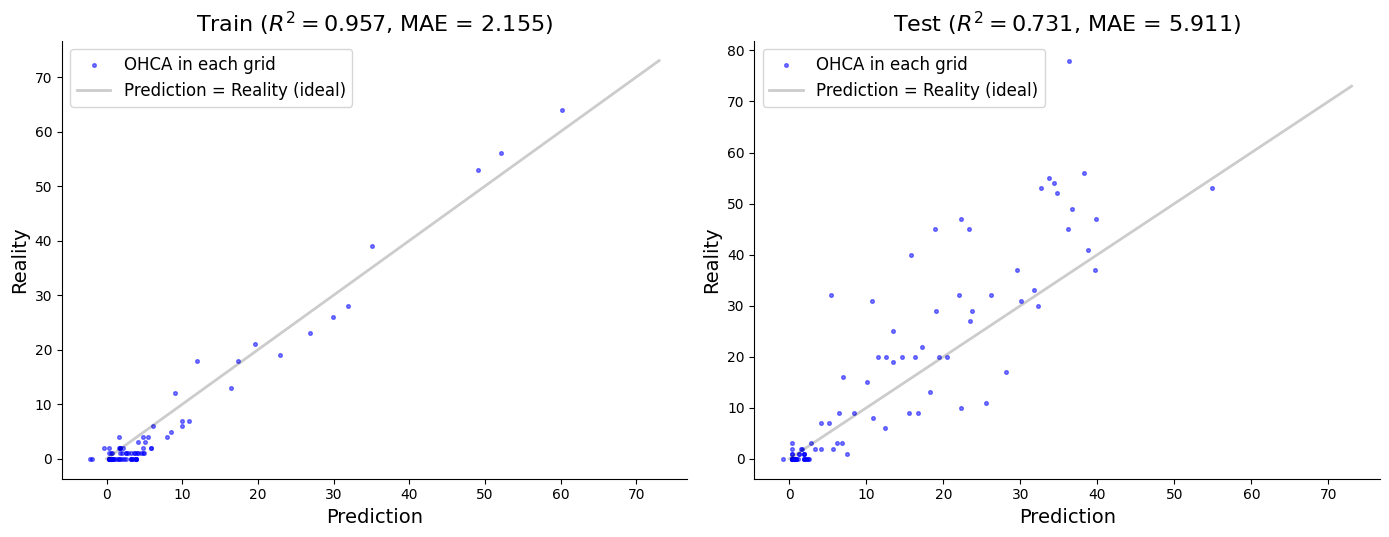

In [12]:
# 建立圖表
fig = plt.figure(figsize=(14, 10))

# 子圖 1：訓練集
ax1 = fig.add_subplot(221)
ax1.scatter(y_head_train, y_train, c="blue", alpha=0.5, label="OHCA in each grid", s=7)
ax1.plot([0, 73], [0, 73], color="black", linewidth=2, label="Prediction = Reality (ideal)", alpha=0.2)
ax1.set_title("Train ($R^2 =$" +str(round(train_r_squared,3)) + ", MAE = " + str(round(train_ans_mae,3)) + ")", fontsize=16)
ax1.set_xlabel("Prediction", fontsize=14)
ax1.set_ylabel("Reality", fontsize=14)
ax1.legend(fontsize=12)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# 子圖 2：測試集
ax2 = fig.add_subplot(222)
ax2.scatter(y_head_test, y_test, c="blue", alpha=0.5, label="OHCA in each grid", s=7)
ax2.plot([0, 73], [0, 73], color="black", linewidth=2, label="Prediction = Reality (ideal)", alpha=0.2)
ax2.set_title("Test ($R^2 =$" +str(round(test_r_squared,3)) + ", MAE = " + str(round(test_ans_mae,3)) + ")", fontsize=16)
ax2.set_xlabel("Prediction", fontsize=14)
ax2.set_ylabel("Reality", fontsize=14)
ax2.legend(fontsize=12)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# 調整布局
plt.tight_layout()
plt.show()

# 繪製實驗結果

In [8]:
# 将 y_head_test 添加为新的列
test_h3_l7_df.loc[:, "y_head_test"] = y_head_test

# 检查结果
test_h3_l7_df

C:\Users\Yuan\AppData\Local\Temp\ipykernel_8336\65216883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_h3_l7_df.loc[:, "y_head_test"] = y_head_test


,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca,y_head_test
0,872af0424ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.355400
1,872af0425ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.319067
2,872af0426ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0.319067
5,872af0502ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1.843997
6,872af0503ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.305069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,872af6370ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,25,13.434318
170,872af6371ffffff,2,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,5.723305
171,872af6372ffffff,3,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,20,19.388586
172,872af6373ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,4.141730


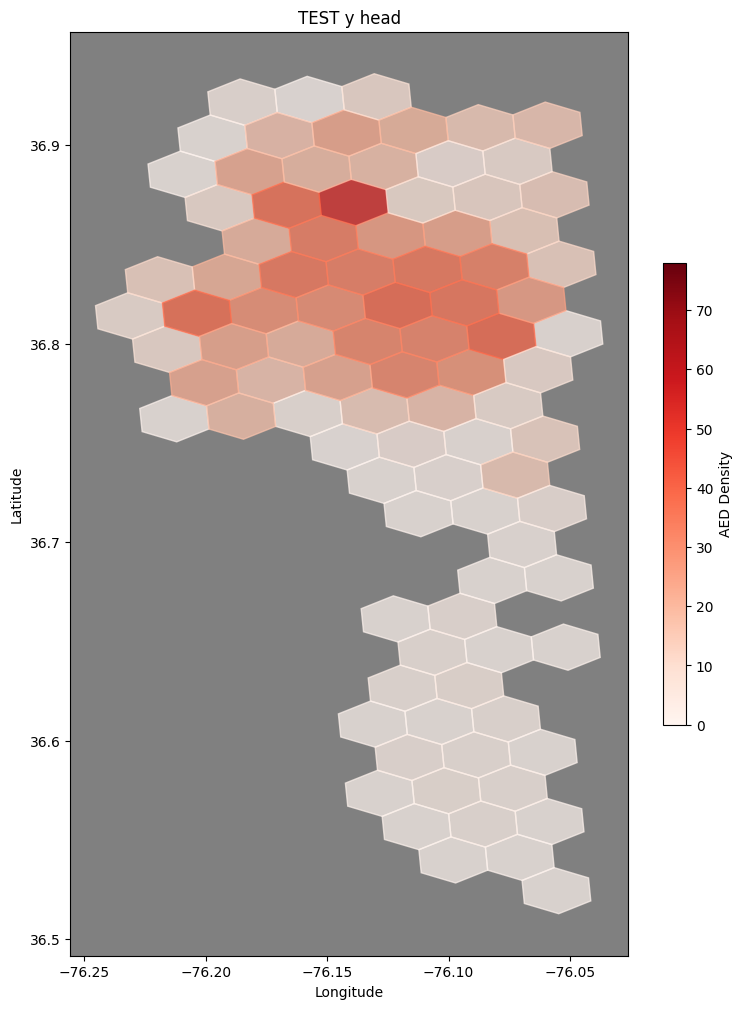

In [9]:
# Step 3: 繪製行政區背景
fig, ax = plt.subplots(figsize=(9, 12))

# Step 4: 計算各網格內的 AED 密度
density_test = test_h3_l7_df[['id', 'y_head_test']]

# Step 5: 繪製每個網格
for index, row in density_test.iterrows():
    # 將 H3 索引轉換為多邊形
    boundary = h3.h3_to_geo_boundary(row['id'], geo_json=True)
    polygon = Polygon(boundary)
    # 根據密度決定顏色
    color_norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
    color = plt.cm.Reds(color_norm(row['y_head_test']))
    ax.fill(*zip(*polygon.exterior.coords), color=color, alpha=0.7)

# Step 6: 創建並顯示顏色條
norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation='vertical', label='AED Density', shrink=0.5)

# Step 7: 設定地圖的細節
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('TEST y head')
ax.set_facecolor('grey')

# 顯示地圖
plt.show()


# fig.savefig('../../outputs/figures/maps/AED_Shenzhen.png')

In [10]:
# 将 y_head_train 添加为新的列
train_h3_l7_df.loc[:, "y_head_train"] = y_head_train

# 检查结果
train_h3_l7_df

C:\Users\Yuan\AppData\Local\Temp\ipykernel_8336\660158301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_h3_l7_df.loc[:, "y_head_train"] = y_head_train


,id,place_of_worship,grave_yard,school,post_office,childcare,university,courthouse,fire_station,library,...,sports_centre,detached,boathouse,barn,riding_hall,construction,ship,ruins,ohca,y_head_train
3,872af0500ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.723224
4,872af0501ffffff,0,0,1,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,3.870603
7,872af0504ffffff,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,4.061487
8,872af0505ffffff,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3.644981
9,872af0509ffffff,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0.328302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,872af636dffffff,4,0,3,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,56,52.138101
168,872af636effffff,2,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,26,29.938099
174,872af6acaffffff,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1.991322
175,872af6ad9ffffff,2,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,2,2.204820


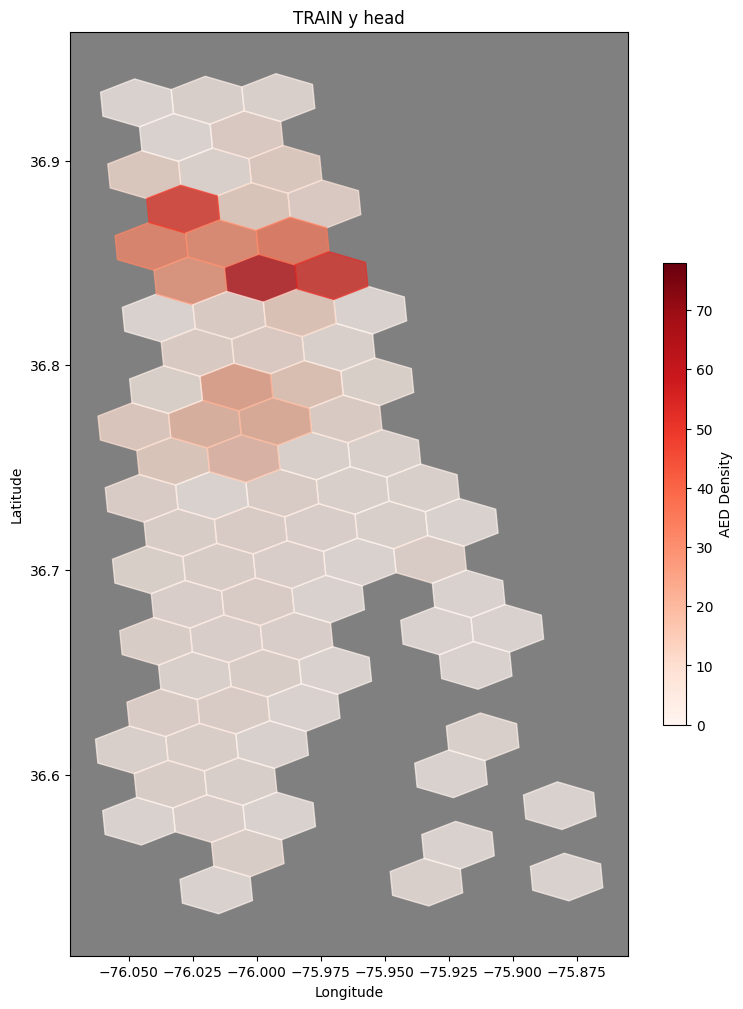

In [11]:
# Step 3: 繪製行政區背景
fig, ax = plt.subplots(figsize=(9, 12))

# Step 4: 計算各網格內的 AED 密度
density_train = train_h3_l7_df[['id', 'y_head_train']]

# Step 5: 繪製每個網格
for index, row in density_train.iterrows():
    # 將 H3 索引轉換為多邊形
    boundary = h3.h3_to_geo_boundary(row['id'], geo_json=True)
    polygon = Polygon(boundary)
    # 根據密度決定顏色
    color_norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
    color = plt.cm.Reds(color_norm(row['y_head_train']))
    ax.fill(*zip(*polygon.exterior.coords), color=color, alpha=0.7)

# Step 6: 創建並顯示顏色條
norm = mcolors.Normalize(vmin=density['ohca'].min(), vmax=density['ohca'].max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation='vertical', label='AED Density', shrink=0.5)

# Step 7: 設定地圖的細節
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('TRAIN y head')
ax.set_facecolor('grey')

# 顯示地圖
plt.show()
